<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Ensemble_and_Comparative_Analysis_of_Machine_Learning_Models_for_Multi_Class_Epileptic_Seizure_Detection_Using_16_Channel_EEG_Signals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [5]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/BEED_Data.csv')
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['y'].value_counts())

# Check for missing values
print("\nMissing Values:", df.isnull().sum().sum())
df.head()


Dataset Shape: (8000, 17)

Class Distribution:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

Missing Values: 0


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0



=== Starting EDA ===


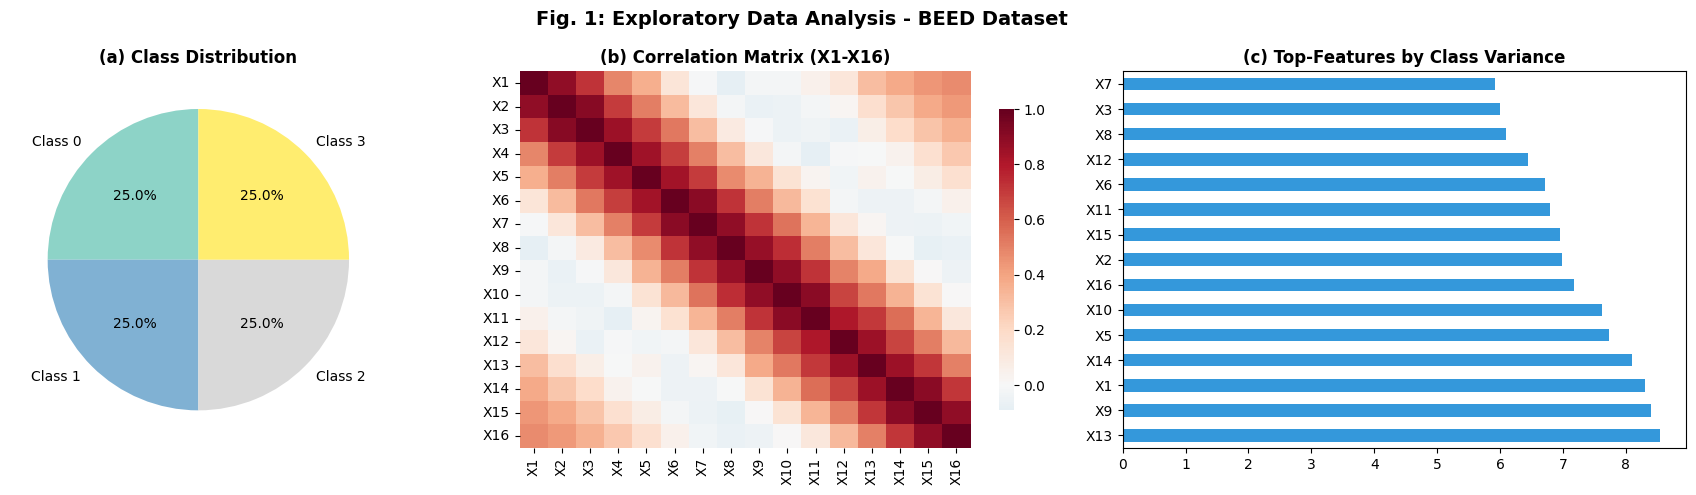

In [6]:
# ─── Exploratory Data Analysis (EDA) ───
print("\n=== Starting EDA ===")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Class Distribution
class_counts = df['y'].value_counts().sort_index()
labels = [f'Class {i}' for i in range(4)]
axes[0].pie(class_counts, labels=labels, autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, 4)), startangle=90)
axes[0].set_title("(a) Class Distribution", fontweight="bold")

# (b) Correlation Heatmap (Channels)
corr = df.iloc[:, :16].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("(b) Correlation Matrix (X1-X16)", fontweight="bold")

# (c) Top Features by Class Variance
feature_means = df.groupby('y').mean().T
mean_diff = feature_means.std(axis=1).sort_values(ascending=False).head(15)
mean_diff.plot.barh(ax=axes[2], color="#3498db")
axes[2].set_title("(c) Top-Features by Class Variance", fontweight="bold")

plt.suptitle("Fig. 1: Exploratory Data Analysis - BEED Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()


In [7]:
X = df.drop('y', axis=1)
y = df['y']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (important for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessed | Train:", X_train.shape, "Test:", X_test.shape)

✅ Data Preprocessed | Train: (6400, 16) Test: (1600, 16)


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=10, gamma="scale", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=400, random_state=42, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(n_estimators=400, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=400, random_state=42, verbose=0)
}

# Ensemble Model (Voting Classifier)
ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=400, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=400, random_state=42, eval_metric='mlogloss')),
        ('lgb', LGBMClassifier(n_estimators=400, random_state=42, verbose=-1)),
        ('cat', CatBoostClassifier(iterations=400, random_state=42, verbose=0))
    ],
    voting='soft'
)


=== Logistic Regression ===
Accuracy: 0.4544 | Precision: 0.4833 | Recall: 0.4544 | F1: 0.4609

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.51      0.61       400
           1       0.49      0.59      0.54       400
           2       0.36      0.38      0.37       400
           3       0.31      0.34      0.32       400

    accuracy                           0.45      1600
   macro avg       0.48      0.45      0.46      1600
weighted avg       0.48      0.45      0.46      1600



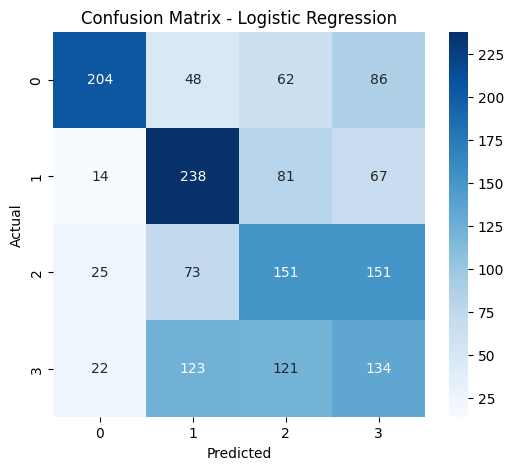


=== KNN ===
Accuracy: 0.9706 | Precision: 0.9713 | Recall: 0.9706 | F1: 0.9707

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       400
           1       0.98      0.95      0.97       400
           2       0.96      0.97      0.97       400
           3       0.94      0.99      0.96       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



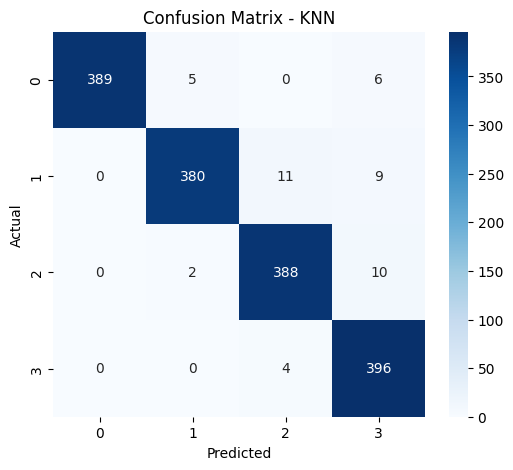


=== SVM ===
Accuracy: 0.8231 | Precision: 0.8418 | Recall: 0.8231 | F1: 0.8194

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.91      0.82      0.86       400
           2       0.65      0.94      0.77       400
           3       0.80      0.54      0.65       400

    accuracy                           0.82      1600
   macro avg       0.84      0.82      0.82      1600
weighted avg       0.84      0.82      0.82      1600



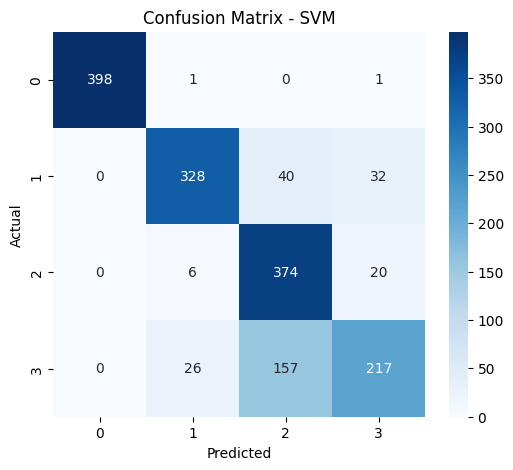


=== Random Forest ===
Accuracy: 0.9656 | Precision: 0.9658 | Recall: 0.9656 | F1: 0.9657

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.97      0.98       400
           2       0.94      0.95      0.95       400
           3       0.95      0.94      0.94       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



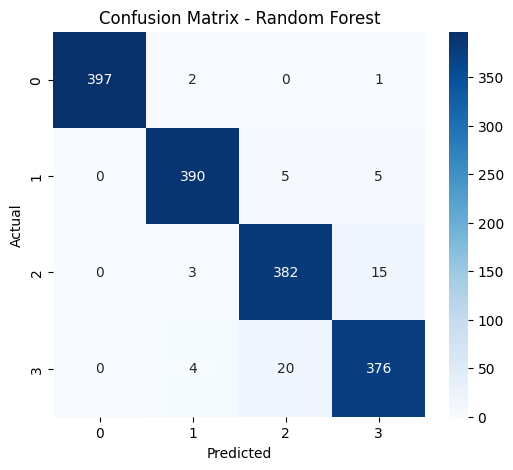


=== XGBoost ===
Accuracy: 0.9781 | Precision: 0.9782 | Recall: 0.9781 | F1: 0.9782

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.99      0.98      0.98       400
           2       0.97      0.96      0.97       400
           3       0.96      0.97      0.97       400

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



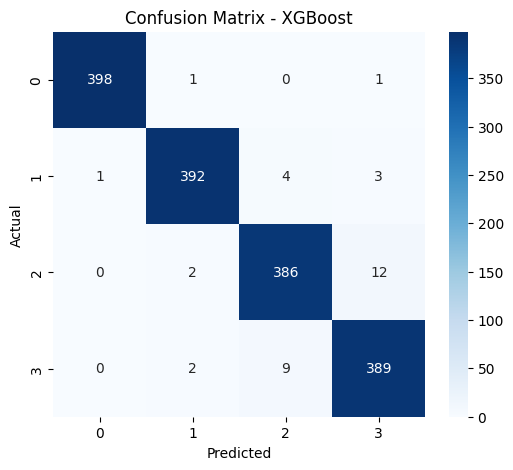


=== LightGBM ===
Accuracy: 0.9856 | Precision: 0.9857 | Recall: 0.9856 | F1: 0.9856

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      0.98      0.99       400
           2       0.97      0.97      0.97       400
           3       0.97      0.99      0.98       400

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



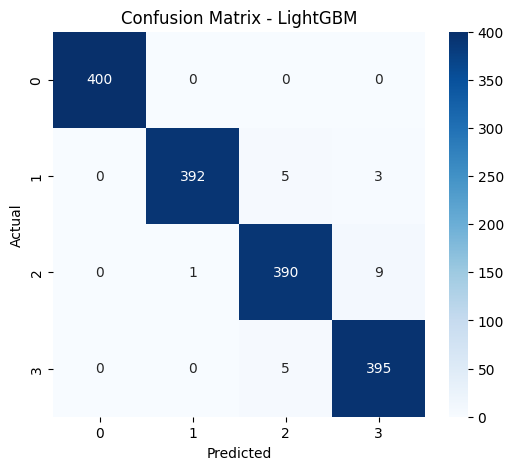


=== CatBoost ===
Accuracy: 0.9700 | Precision: 0.9702 | Recall: 0.9700 | F1: 0.9701

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.97      0.97       400
           2       0.95      0.96      0.96       400
           3       0.95      0.95      0.95       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



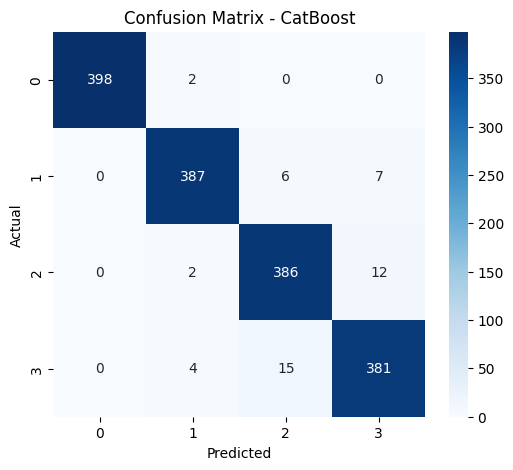


=== Ensemble (Voting) ===
Accuracy: 0.9844 | Precision: 0.9845 | Recall: 0.9844 | F1: 0.9844

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.99      0.98      0.99       400
           2       0.97      0.97      0.97       400
           3       0.97      0.98      0.98       400

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



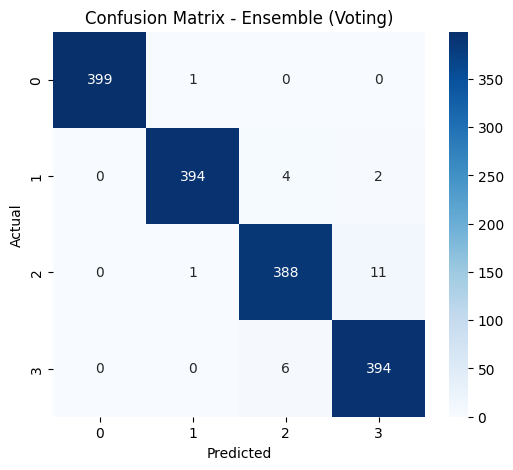

In [15]:
results = []

def evaluate_model(name, model, X_tr, X_te):
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
    else:
        model.fit(X_train, y_train)  # Tree models handle unscaled data well
        pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='macro')
    rec = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Train Individual Models
for name, model in models.items():
    evaluate_model(name, model, X_train_scaled, X_test_scaled)

# Train Ensemble
evaluate_model("Ensemble (Voting)", ensemble, X_train, X_test)


📊 Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.4544     0.4833  0.4544    0.4609
1                  KNN    0.9706     0.9713  0.9706    0.9707
2                  SVM    0.8231     0.8418  0.8231    0.8194
3        Random Forest    0.9656     0.9658  0.9656    0.9657
4              XGBoost    0.9781     0.9782  0.9781    0.9782
5             LightGBM    0.9856     0.9857  0.9856    0.9856
6             CatBoost    0.9700     0.9702  0.9700    0.9701
7    Ensemble (Voting)    0.9844     0.9845  0.9844    0.9844


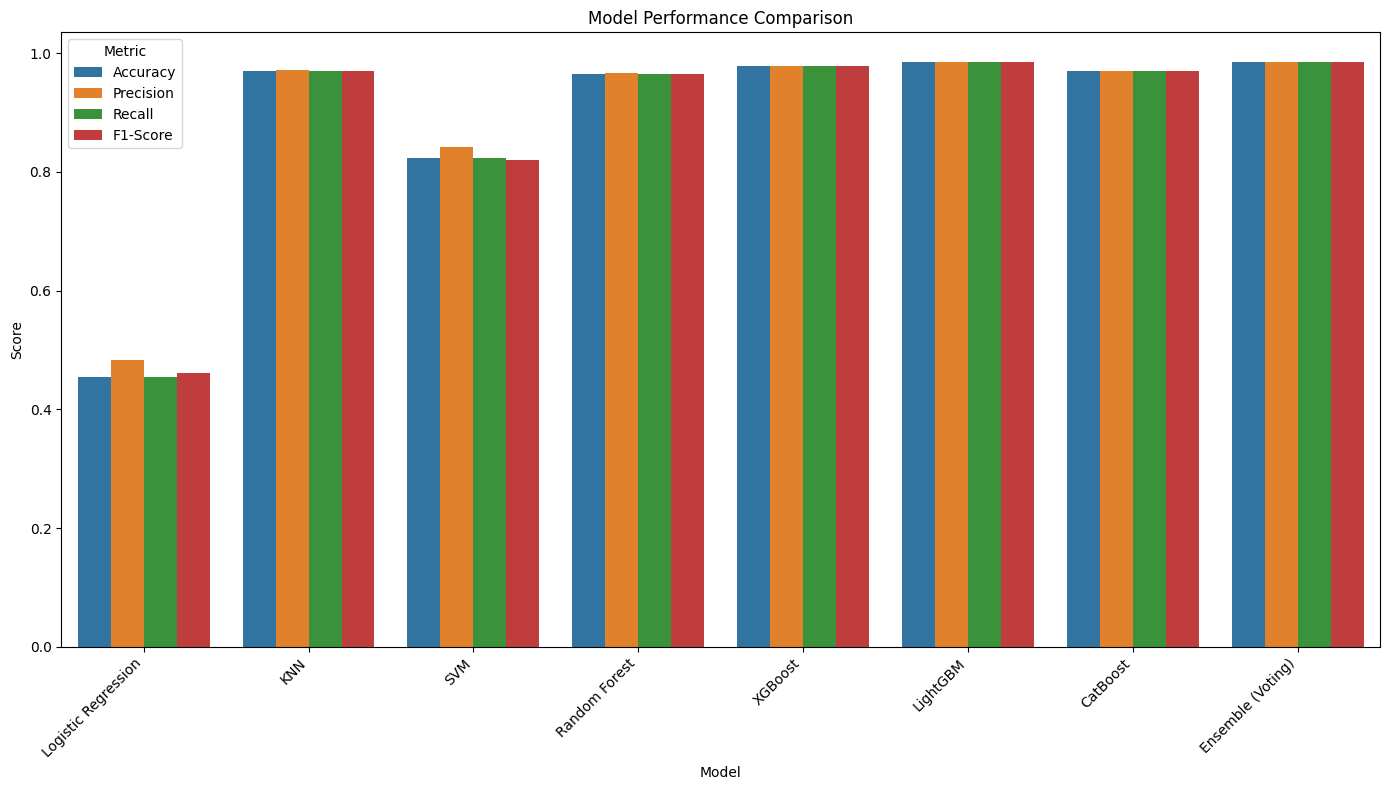


 Best Model: LightGBM with F1-Score: 0.9856


In [16]:
results_df = pd.DataFrame(results)
print("\n📊 Model Comparison Table:")
print(results_df.round(4))

# Bar Plot Comparison
plt.figure(figsize=(14, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_melt = pd.melt(results_df, id_vars=['Model'], value_vars=metrics)

sns.barplot(x='Model', y='value', hue='variable', data=results_melt)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Highlight Best Model
best_model = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\n Best Model: {best_model['Model']} with F1-Score: {best_model['F1-Score']:.4f}")

In [17]:
# Find best model from results table
best_row = results_df.loc[results_df['F1-Score'].idxmax()]

best_model_name = best_row['Model']

print("Best Model:", best_model_name)
print("Best F1 Score:", best_row['F1-Score'])

# Get model object
if best_model_name == "Ensemble (Voting)":
    best_model_obj = ensemble
else:
    best_model_obj = models[best_model_name]

Best Model: LightGBM
Best F1 Score: 0.9856462545569895


In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# 5-Fold Stratified CV
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Use scaled data only for LR, KNN, SVM
if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
    X_cv = scaler.fit_transform(X)
else:
    X_cv = X

# Accuracy CV
cv_scores = cross_val_score(
    best_model_obj,
    X_cv,
    y,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

print("\n===== 5-Fold Cross Validation =====")
print("Fold Scores:")
print(np.round(cv_scores, 4))

print("\nMean Accuracy :", round(cv_scores.mean(), 4))
print("Std Deviation :", round(cv_scores.std(), 4))
print("Best Fold     :", round(cv_scores.max(), 4))
print("Worst Fold    :", round(cv_scores.min(), 4))


===== 5-Fold Cross Validation =====
Fold Scores:
[0.9844 0.9856 0.9812 0.9756 0.98  ]

Mean Accuracy : 0.9814
Std Deviation : 0.0035
Best Fold     : 0.9856
Worst Fold    : 0.9756


In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

In [20]:
n_classes = len(np.unique(y))

# Convert labels to one-hot format
y_test_bin = label_binarize(y_test, classes=np.unique(y))

Processing Logistic Regression...
Processing KNN...
Processing SVM...
Processing Random Forest...
Processing XGBoost...
Processing LightGBM...
Processing CatBoost...


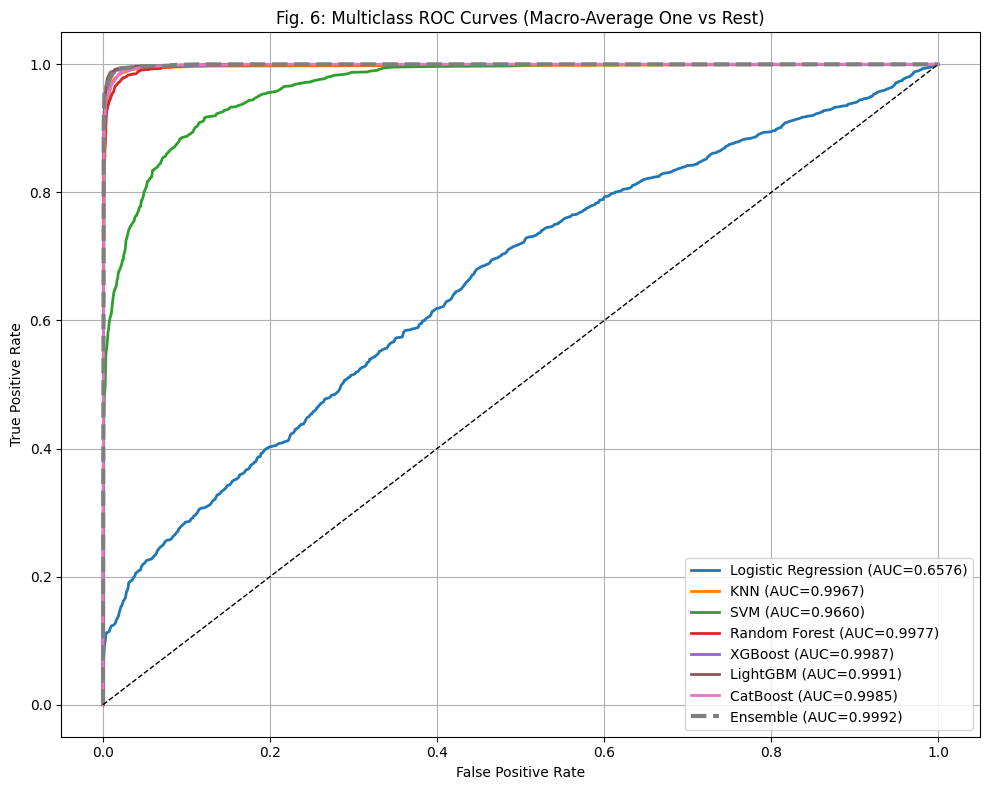

In [22]:
plt.figure(figsize=(10,8))

roc_auc_results = {}

for name, model in models.items():

    print(f"Processing {name}...")

    # Scale-dependent models
    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)

        y_score = model.predict_proba(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_score = model.predict_proba(X_test)

    # -------------------------
    # Macro AUC (CORRECT WAY)
    # -------------------------

    macro_auc = roc_auc_score(
        y_test_bin,
        y_score,
        multi_class='ovr',
        average='macro'
    )

    roc_auc_results[name] = macro_auc

    # -------------------------
    # Macro ROC Curve
    # -------------------------

    fpr = {}
    tpr = {}

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

    all_fpr = np.unique(
        np.concatenate([fpr[i] for i in range(n_classes)])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= n_classes

    # Force ROC to start at (0,0) and end at (1,1)
    mean_tpr[0] = 0.0
    mean_tpr[-1] = 1.0

    plt.plot(
        all_fpr,
        mean_tpr,
        lw=2,
        label=f"{name} (AUC={macro_auc:.4f})"
    )

# -------------------------
# Ensemble Model
# -------------------------

ensemble.fit(X_train, y_train)

ensemble_score = ensemble.predict_proba(X_test)

ensemble_auc = roc_auc_score(
    y_test_bin,
    ensemble_score,
    multi_class='ovr',
    average='macro'
)

roc_auc_results["Ensemble"] = ensemble_auc

fpr = {}
tpr = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        ensemble_score[:, i]
    )

all_fpr = np.unique(
    np.concatenate([fpr[i] for i in range(n_classes)])
)

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):

    mean_tpr += np.interp(
        all_fpr,
        fpr[i],
        tpr[i]
    )

mean_tpr /= n_classes

mean_tpr[0] = 0.0
mean_tpr[-1] = 1.0

plt.plot(
    all_fpr,
    mean_tpr,
    lw=3,
    linestyle='--',
    label=f"Ensemble (AUC={ensemble_auc:.4f})"
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    'k--',
    lw=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fig. 6: Multiclass ROC Curves (Macro-Average One vs Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
roc_df = pd.DataFrame(
    roc_auc_results.items(),
    columns=["Model","AUC-ROC"]
)

roc_df = roc_df.sort_values(
    "AUC-ROC",
    ascending=False
)

print("\nROC-AUC Comparison")
print(roc_df.round(4))


ROC-AUC Comparison
                 Model  AUC-ROC
7             Ensemble   0.9992
5             LightGBM   0.9991
4              XGBoost   0.9987
6             CatBoost   0.9985
3        Random Forest   0.9977
1                  KNN   0.9967
2                  SVM   0.9660
0  Logistic Regression   0.6576


   Feature  Importance
4       X5        3138
7       X8        2903
5       X6        2850
6       X7        2784
15     X16        2669
11     X12        2651
3       X4        2625
2       X3        2599
8       X9        2553
10     X11        2512
12     X13        2473
14     X15        2395
0       X1        2354
1       X2        2318
13     X14        2282
9      X10        2205


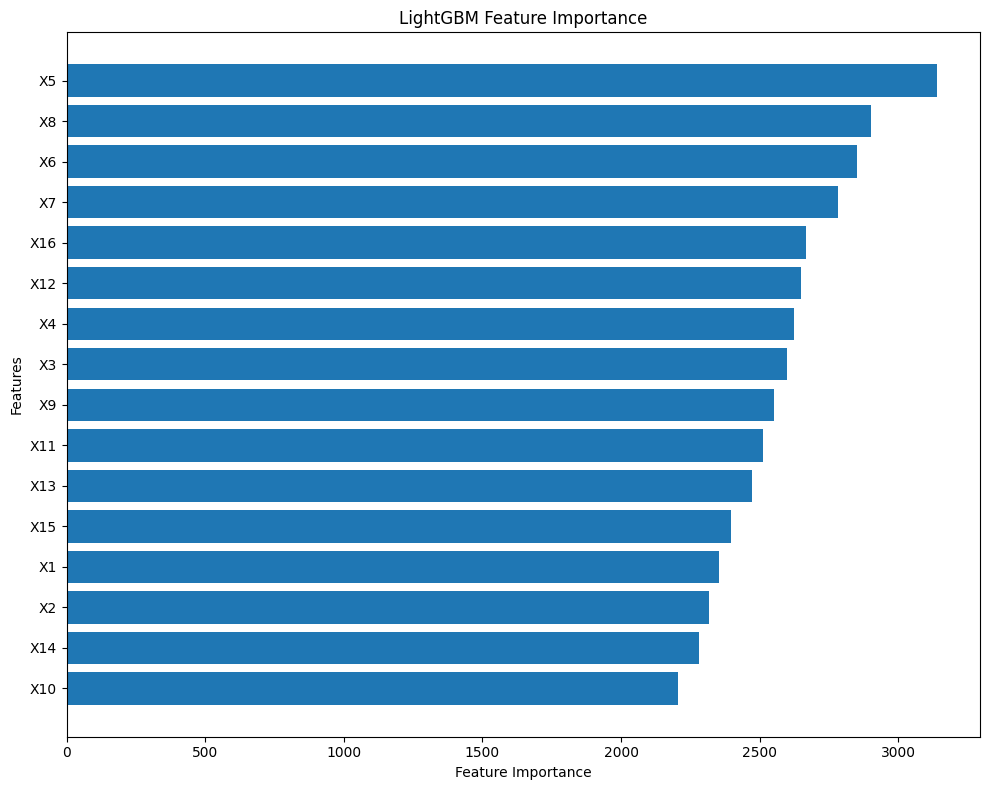

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Train LightGBM
lgb_model = LGBMClassifier(
    n_estimators=400,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

# Gain importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(16))
top_n = 16

plt.figure(figsize=(10,8))

plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

In [33]:
!pip install -q shap

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train best model on full training data
best_model = LGBMClassifier(
    n_estimators=400,
    random_state=42,
    verbose=-1
)

best_model.fit(X_train, y_train)

# SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("Type:", type(shap_values))
print("Number of classes:", len(shap_values))

Type: <class 'numpy.ndarray'>
Number of classes: 1600


In [ ]:
# New SHAP versions
if isinstance(shap_values, np.ndarray):

    # shape = (samples, features, classes)
    mean_shap = np.mean(np.abs(shap_values), axis=(0, 2))

else:

    # Older SHAP versions
    mean_shap = np.mean(
        [np.abs(class_shap) for class_shap in shap_values],
        axis=(0, 1)
    )

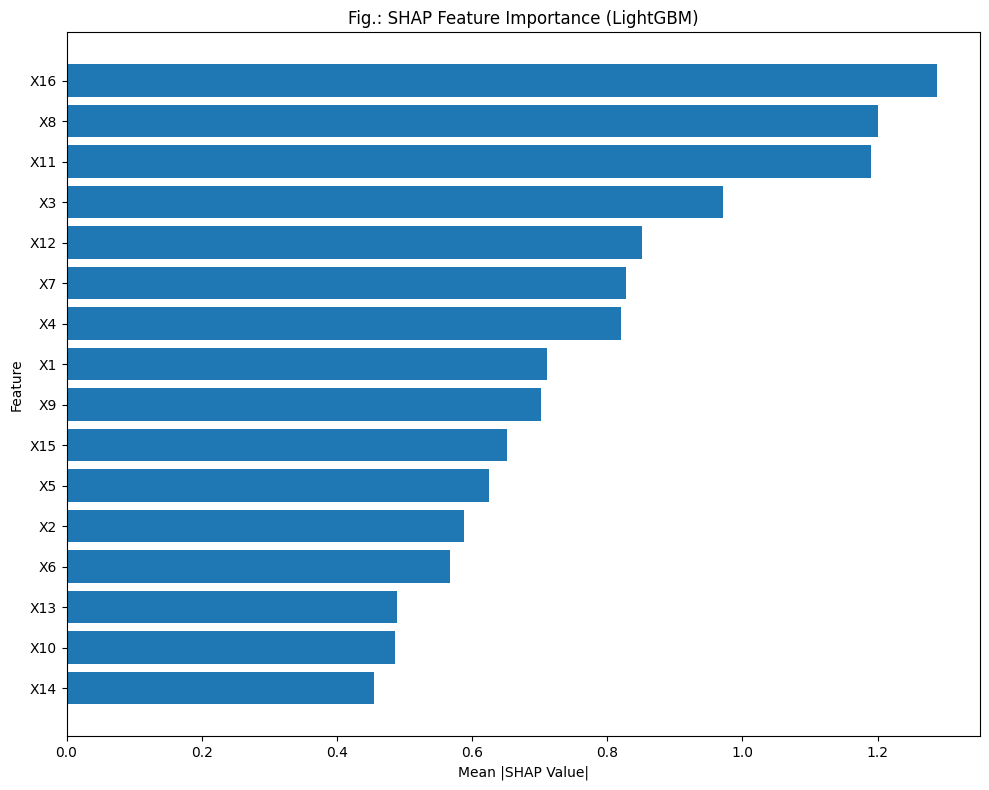

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'SHAP Importance': mean_shap
})

feature_importance = feature_importance.sort_values(
    'SHAP Importance',
    ascending=False
)

top_n = 20

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance['Feature'].head(top_n)[::-1],
    feature_importance['SHAP Importance'].head(top_n)[::-1]
)

plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')
plt.title('Fig.: SHAP Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train LightGBM
best_model = LGBMClassifier(
    n_estimators=400,
    random_state=42,
    verbose=-1
)

best_model.fit(X_train, y_train)

# SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# SHAP values
shap_values = explainer.shap_values(X_test)

print(type(shap_values))

<class 'numpy.ndarray'>


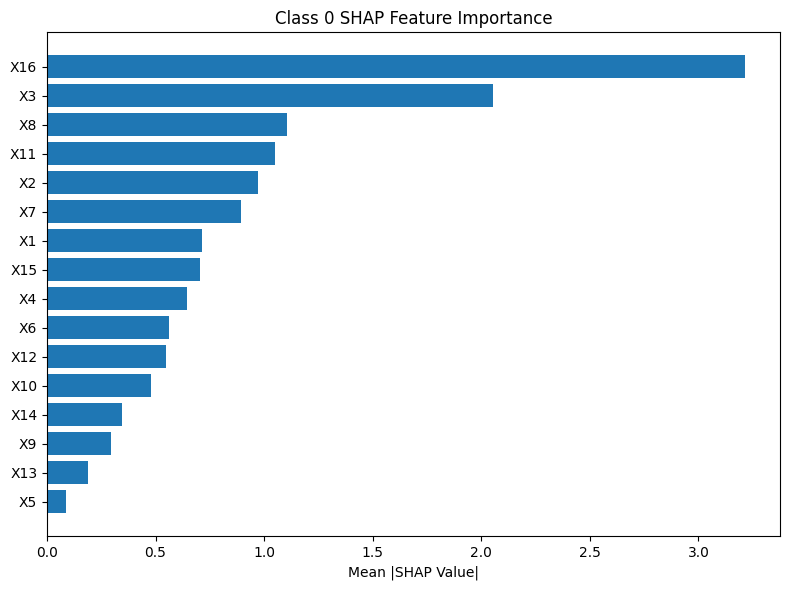

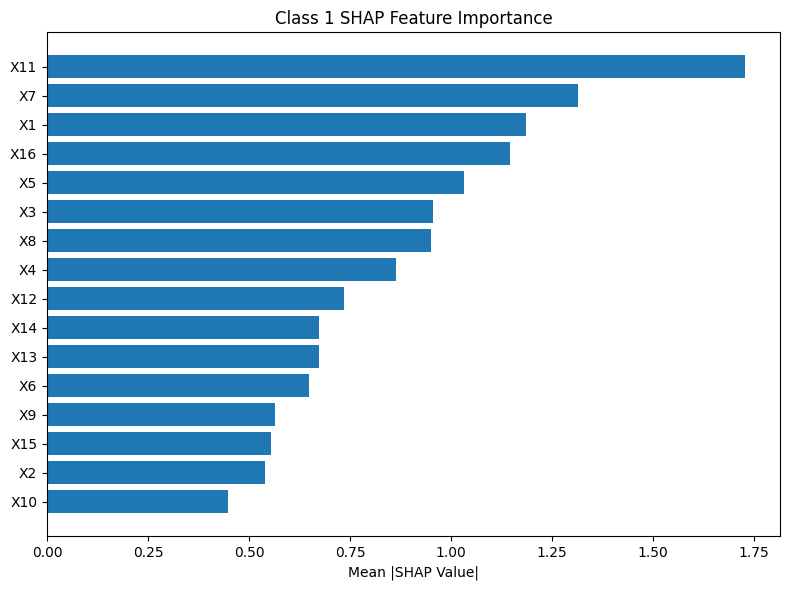

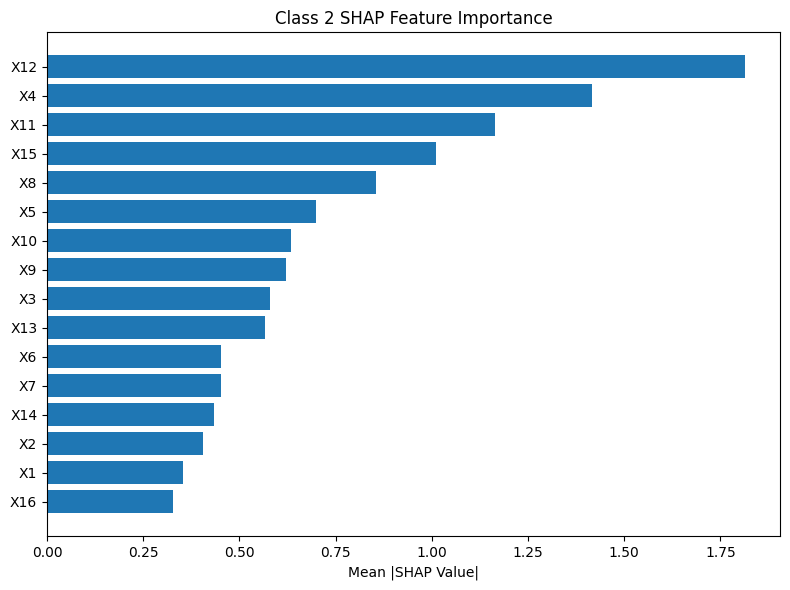

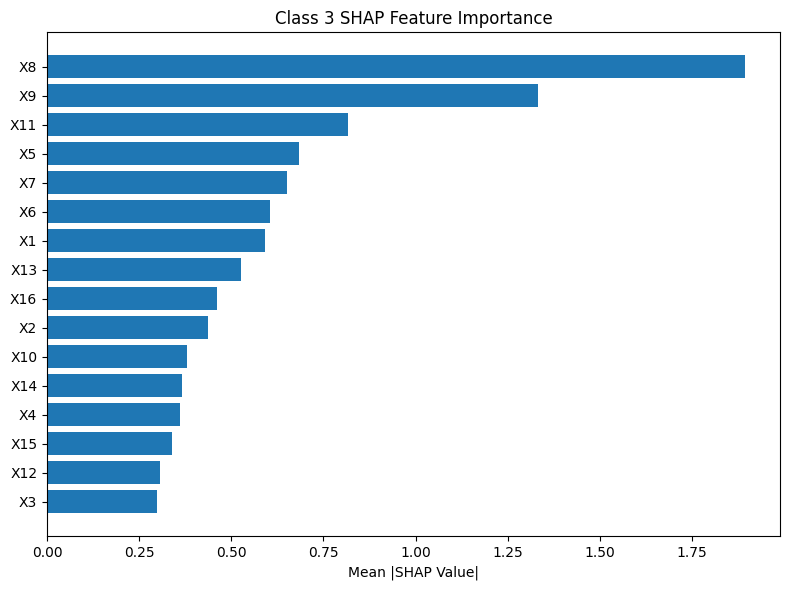

In [ ]:
# New SHAP version
if isinstance(shap_values, np.ndarray):

    # shape = (samples, features, classes)

    n_classes = shap_values.shape[2]

    for c in range(n_classes):

        class_importance = np.mean(
            np.abs(shap_values[:, :, c]),
            axis=0
        )

        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': class_importance
        })

        importance_df = importance_df.sort_values(
            'Importance',
            ascending=False
        ).head(16)

        plt.figure(figsize=(8,6))

        plt.barh(
            importance_df['Feature'][::-1],
            importance_df['Importance'][::-1]
        )

        plt.title(f"Class {c} SHAP Feature Importance")
        plt.xlabel("Mean |SHAP Value|")
        plt.tight_layout()
        plt.show()

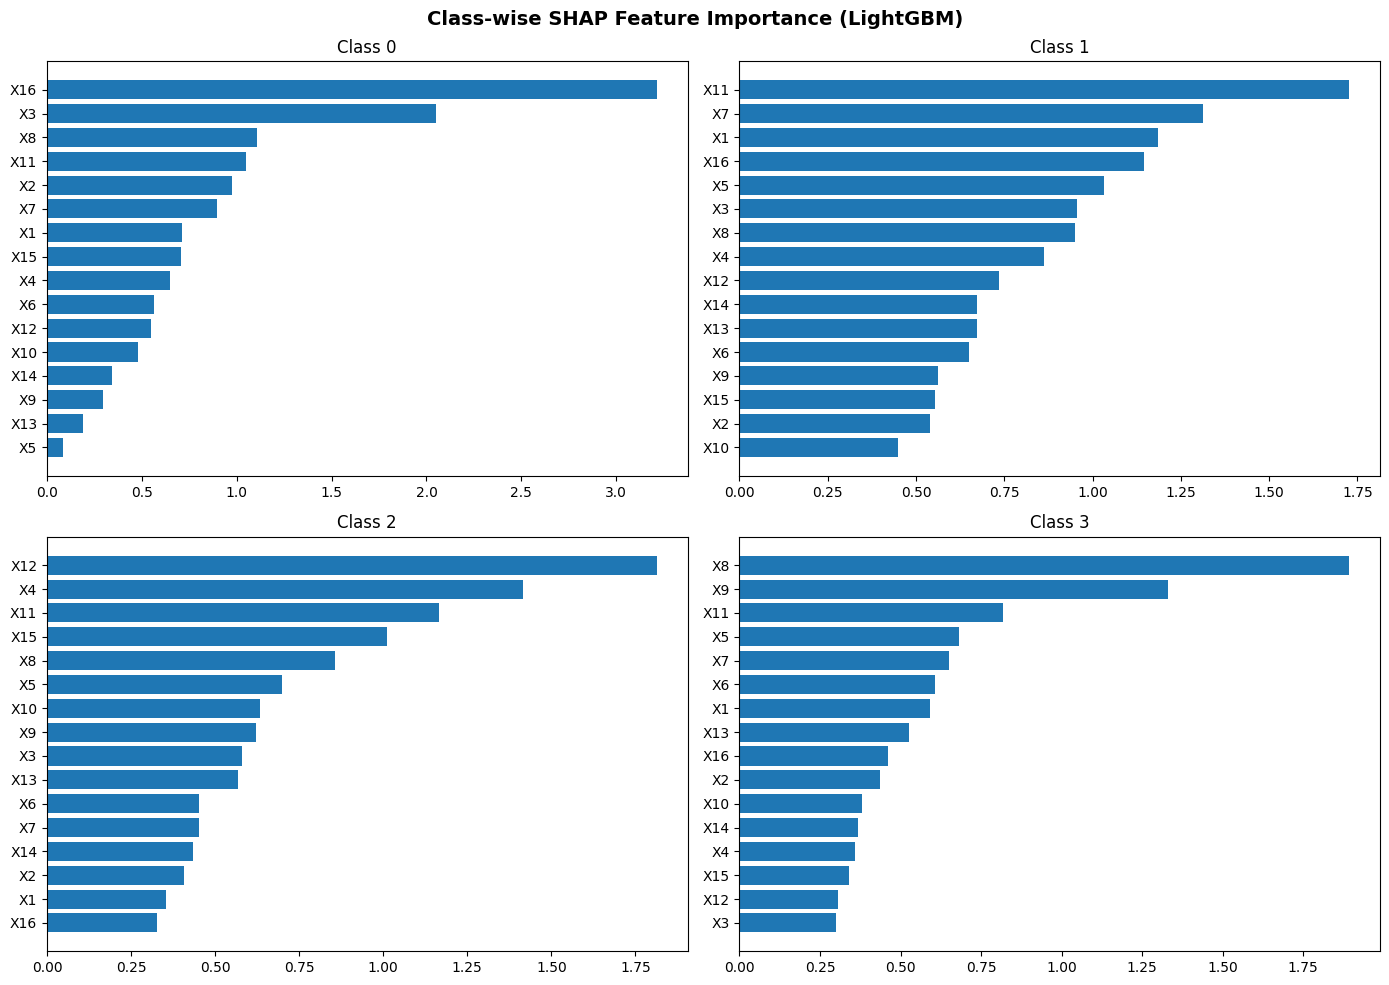

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for c in range(4):

    if isinstance(shap_values, np.ndarray):
        class_imp = np.mean(
            np.abs(shap_values[:, :, c]),
            axis=0
        )
    else:
        class_imp = np.mean(
            np.abs(shap_values[c]),
            axis=0
        )

    imp_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': class_imp
    })

    imp_df = imp_df.sort_values(
        'Importance',
        ascending=False
    ).head(16)

    axes[c].barh(
        imp_df['Feature'][::-1],
        imp_df['Importance'][::-1]
    )

    axes[c].set_title(f"Class {c}")

plt.suptitle(
    "Class-wise SHAP Feature Importance (LightGBM)",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()